In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
import torch
import CustomModules.CAE_Utils as CAE_Utils
from datasets import load_dataset
import matplotlib.pyplot as plt

c:\Users\anton\miniconda3\envs\Geometric-Deep-Learning\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [4]:
from torch.utils.data import Dataset
from torchvision import datasets

In [5]:
mnist = datasets.MNIST(root='data', train=True, download=True, transform=None)
mnist_test = datasets.MNIST(root='data', train=False, download=True, transform=None)

In [6]:

X_data = mnist.data.float()
X_data_test = mnist_test.data.float()

X_data = X_data / 255.0
X_data_test = X_data_test / 255.0

X_data = X_data.reshape(-1, 28*28)
X_data_test = X_data_test.reshape(-1, 28*28)

X_loader = torch.utils.data.DataLoader(X_data, batch_size=1024, shuffle=True)
X_loader_test = torch.utils.data.DataLoader(X_data_test, batch_size=1024, shuffle=False)

(array([  2., 285., 428.,  29.,  23.,  12.,  19.,  75.,   4., 123.]),
 array([0. , 0.9, 1.8, 2.7, 3.6, 4.5, 5.4, 6.3, 7.2, 8.1, 9. ]),
 <BarContainer object of 10 artists>)

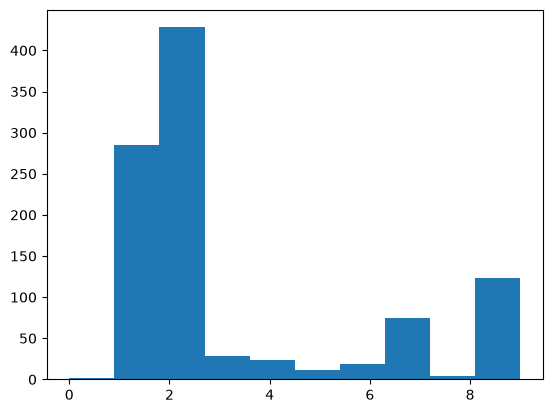

In [26]:
cae = CAE_Utils.CAE(m =784, l=400, d=10, 
                    hidden_dim=128, 
                    hidden_chart_dim =128, 
                    hidden_predictor_dim=10,
                    chart_amount=10)

CAE_Utils.pre_train_cae(num_epochs=10, x_train=X_data, network=cae, device=device)

# sample 1000 datapoints from x_data:
X_data_sample = X_data[torch.randperm(X_data.size(0))[:1000]]
maxes = torch.argmax(cae.predict(X_data_sample), dim=1)
plt.hist(maxes.cpu().numpy())

In [52]:
diag = CAE_Utils.train_cae(num_epochs=30, x_train_loader=X_loader, network=cae, device=device)

  0%|          | 0/30 [00:00<?, ?it/s]


RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

(array([   0.,    0.,    0.,    0.,    0., 1000.,    0.,    0.,    0.,
           0.]),
 array([2.5, 2.6, 2.7, 2.8, 2.9, 3. , 3.1, 3.2, 3.3, 3.4, 3.5]),
 <BarContainer object of 10 artists>)

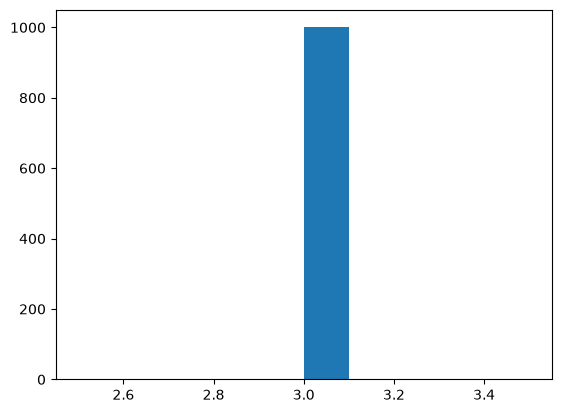

In [36]:
# sample 1000 datapoints from x_data:
X_data_sample = X_data[torch.randperm(X_data.size(0))[:1000]]
predictions = cae.predict(X_data_sample.to(device))
maxes = torch.argmax(predictions, dim=1)
plt.hist(maxes.cpu().numpy())

In [54]:
hej = (1,2,3)

In [62]:
term1, term2, term3, term4 = zip(*diag)
term1 = list(term1)
term2 = list(term2)
term3 = list(term3)
term4 = list(term4)
for i in range(len(term1)):
    term1[i] = term1[i].mean().cpu().detach().numpy()
    term2[i] = term2[i].mean().cpu().detach().numpy()
    term3[i] = term3[i].mean().cpu().detach().numpy()
    term4[i] = term4[i].mean().cpu().detach().numpy()

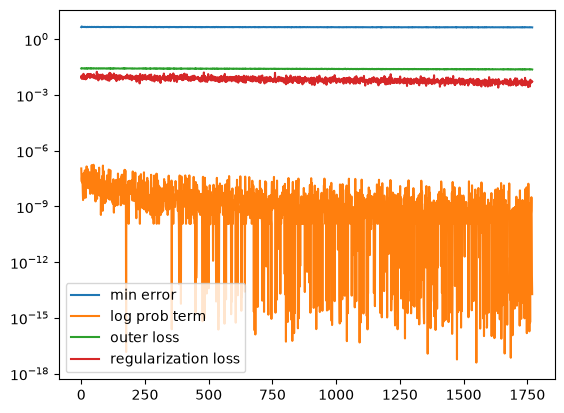

In [68]:
plt.plot(term1, label='min error')
plt.plot(term2, label='log prob term')
plt.plot(term3, label='outer loss')
plt.plot(term4, label='regularization loss')
plt.yscale('log')
plt.legend()
plt.show()


In [30]:
cae.to("cpu")
batch = next(iter(X_loader_test))[0:10]
reconstructed = cae.encode_decode(batch).detach().numpy()



In [31]:
cae.to("cpu")
batch = next(iter(X_loader_test))[0:10]
reconstructed = cae.decode(cae.encode(batch)).detach().numpy()

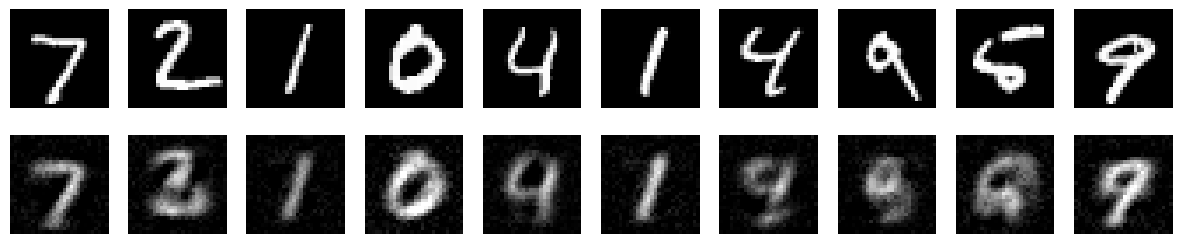

In [32]:

#plot both batch and reconstructed images
fig, axs = plt.subplots(2, 10, figsize=(15, 3))

for i, (image, ax) in enumerate(zip(batch, axs[0])):
    ax.imshow(image.reshape(28, 28), cmap="gray", vmin=0, vmax=1)
    ax.axis("off")

for i, (image, ax) in enumerate(zip(reconstructed, axs[1])):
    ax.imshow(image.reshape(28, 28), cmap="gray", vmin=0, vmax=1)
    ax.axis("off")

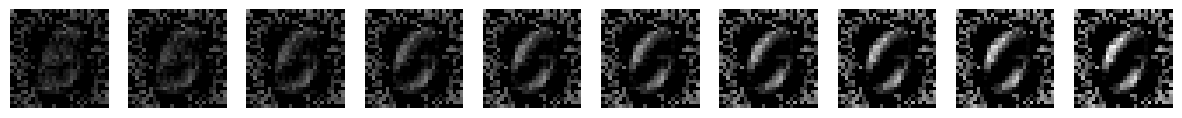

In [ ]:


start_encoded = cae.encode(batch[1].unsqueeze(0))
end_encoded = cae.encode(batch[3].unsqueeze(0))
interpolated = torch.linspace(0, 1, steps=10).unsqueeze(1) * end_encoded + (1 - torch.linspace(0, 1, steps=10).unsqueeze(1)) * start_encoded
decoded_interpolated = cae.decode(interpolated).detach().numpy()
#plot
fig, axs = plt.subplots(1, 10, figsize=(15, 3))
for i, (image, ax) in enumerate(zip(decoded_interpolated, axs)):
    ax.imshow(image.reshape(28, 28), cmap="gray", vmin=0, vmax=1)
    ax.axis("off")



In [10]:

from CustomModules.util import farthest_point_sample


points = torch.randn(500, 3)

sampled, idx = farthest_point_sample(points, 3)

print(sampled)
print(idx)

tensor([[-0.3948,  0.4201, -0.4222],
        [-0.9932, -0.2078,  3.7958],
        [ 2.1075, -2.3150,  1.1269]])
tensor([355,  62, 347])


In [12]:
points + 3

tensor([[2.4016, 2.2153, 3.8495],
        [2.2310, 2.6600, 3.3027],
        [3.7313, 3.1141, 1.2191],
        ...,
        [3.5368, 2.7950, 3.5428],
        [2.1732, 2.8783, 3.6962],
        [2.7963, 2.0487, 1.8663]])